<a href="https://colab.research.google.com/github/AKIData/SDC-Datathon1-2026/blob/main/SDC_June_2026_Financial_Impact_post_Mobile_Money_Datathon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1: Bring the data into the environment

In [51]:
# Import the data set from google drive
from google.colab import drive

drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [52]:
# Download needed tools
!pip install matplotlib pandas openpyxl

In [53]:
# Find the data within the path
path = '/content/drive/MyDrive/finaccess2024_datasprint.xlsx'

print(path)

/content/drive/MyDrive/finaccess2024_datasprint.xlsx


In [54]:
# Get the actual data needed

import pandas as pd

df = pd.read_excel(path)
df.head(5)

,county,location_type,Sex,Age,household_size,education_level,marital_status,monthly_income,Savings_formal,Savings_informal,...,nfhi_11,nfhi_12,nfhi_13,accessto_13k_1month,not_difficult,financial_status,fl_score,prodsum1,barriers_bank,has_disability
0,Garissa,Urban,Female,26-35,5,Completed technical training after secondary s...,Married/Living with partner,30000,Non-usage,Non-usage,...,Yes,Yes,Yes,Yes,No,Stayed the same,All correct,3,NaN,Without Disability
1,Garissa,Urban,Female,Above 55,11,"""None """,Married/Living with partner,10000,Non-usage,Non-usage,...,No,No,Yes,No,No,Worsened,Two correct,1,Affordability,Without Disability
2,Busia,Urban,Female,26-35,2,"""Primary completed""",Divorced/separated,3000,Usage,Usage,...,Yes,No,No,No,No,Improved,All correct,5,Affordability,Without Disability
3,Kiambu,Urban,Male,18-25,1,"""Some secondary""",Single/Never Married,10000,Usage,Non-usage,...,No,No,No,Yes,No,Improved,All correct,4,Affordability,Without Disability
4,Murang'a,Urban,Female,18-25,1,Some technical training after secondary school,Single/Never Married,10000,Usage,Non-usage,...,Yes,Yes,Yes,Yes,Yes,Improved,All correct,5,NaN,Without Disability


Step 2: Handle Missing Values

In [55]:
# Count the number of cells with missing data

print(df.isnull().sum())

county                      0
location_type               0
Sex                         0
Age                         0
household_size              0
education_level             0
marital_status              0
monthly_income              0
Savings_formal              0
Savings_informal            0
Loan_formal                 0
Loan_informal               0
defaulted                   0
formal_service_use          0
mobile_money_access         0
barriers_mobile_money       0
mobile_ownership_1          0
experienced_shock           0
nfhi_11                     0
nfhi_12                     0
nfhi_13                     0
accessto_13k_1month         0
not_difficult               0
financial_status            0
fl_score                    0
prodsum1                    0
barriers_bank            5734
has_disability              0
dtype: int64


#### As shown only barriers to entering the bank are the null values
#### https://www.geopoll.com/blog/kenyas-financial-landscape-report~/#:~:text=According%20to%20the%20FinAccess%20Household,a%20significant%20milestone%20in%20inclusion.&text=The%20country%20is%20globally%20recognized,savings%2C%20and%20access%20to%20credit.
#### Based on the financial report by geopoll (link above):
#### 83% of kenyans have bank accounts with:
<ul>
<li>36% of kenyans engage with them rarely</li>
<li>33% engage monthly</li>
<li>22% engage weekly</li>
<li>11% engage daily</li>
</ul>

#### It is safe to assume that the data follows the same pattern and the 27.5% of users have no barrier to accessing bank details.

In [56]:
df['barriers_bank'] = df['barriers_bank'].fillna("No barrier")
df.head(5)

,county,location_type,Sex,Age,household_size,education_level,marital_status,monthly_income,Savings_formal,Savings_informal,...,nfhi_11,nfhi_12,nfhi_13,accessto_13k_1month,not_difficult,financial_status,fl_score,prodsum1,barriers_bank,has_disability
0,Garissa,Urban,Female,26-35,5,Completed technical training after secondary s...,Married/Living with partner,30000,Non-usage,Non-usage,...,Yes,Yes,Yes,Yes,No,Stayed the same,All correct,3,No barrier,Without Disability
1,Garissa,Urban,Female,Above 55,11,"""None """,Married/Living with partner,10000,Non-usage,Non-usage,...,No,No,Yes,No,No,Worsened,Two correct,1,Affordability,Without Disability
2,Busia,Urban,Female,26-35,2,"""Primary completed""",Divorced/separated,3000,Usage,Usage,...,Yes,No,No,No,No,Improved,All correct,5,Affordability,Without Disability
3,Kiambu,Urban,Male,18-25,1,"""Some secondary""",Single/Never Married,10000,Usage,Non-usage,...,No,No,No,Yes,No,Improved,All correct,4,Affordability,Without Disability
4,Murang'a,Urban,Female,18-25,1,Some technical training after secondary school,Single/Never Married,10000,Usage,Non-usage,...,Yes,Yes,Yes,Yes,Yes,Improved,All correct,5,No barrier,Without Disability


Step 3: Visualise the data

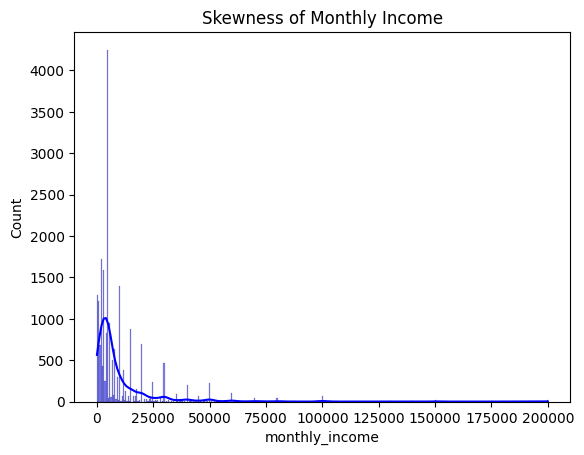

In [57]:
# Determine what is to be cleaned and what is okay to run along with
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=df,x="monthly_income",kde=True,color="blue")

plt.title('Skewness of Monthly Income')
plt.show()

# Data is heavily skewed to the left

Text(0.5, 1.0, 'Location Type')

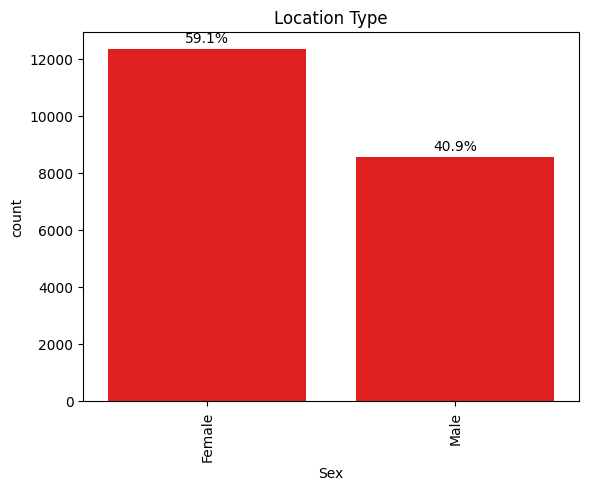

In [58]:
ax = sns.countplot(data=df,x="Sex",color="red")

total_cells =len(df)

for container in ax.containers:
    # Calculate percentages: (height of bar / total rows) * 100
    labels = [f'{(h / total_cells) * 100:.1f}%' if h > 0 else '' for h in container.datavalues]

    # Stick the labels right on top of the bars!
    ax.bar_label(container, labels=labels, label_type='edge', padding=3)

plt.xticks(rotation=90)

plt.title("Location Type")

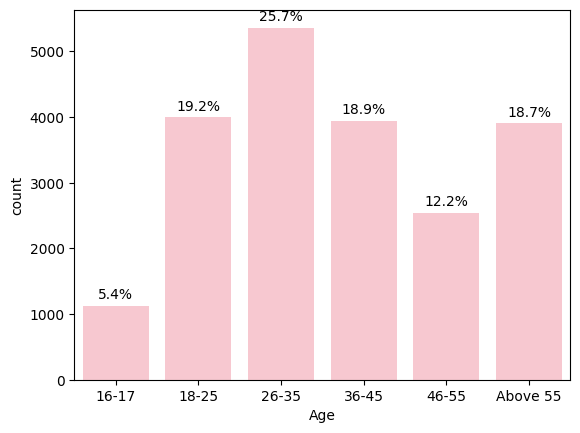

In [59]:
custom_order = ["16-17","18-25","26-35","36-45","46-55","Above 55"]
ax = sns.countplot(data=df,x="Age",order=custom_order,color="pink")

total_cells =len(df)

for container in ax.containers:
    # Calculate percentages: (height of bar / total rows) * 100
    labels = [f'{(h / total_cells) * 100:.1f}%' if h > 0 else '' for h in container.datavalues]

    # Stick the labels right on top of the bars!
    ax.bar_label(container, labels=labels, label_type='edge', padding=3)

Text(0.5, 1.0, 'Data per county')

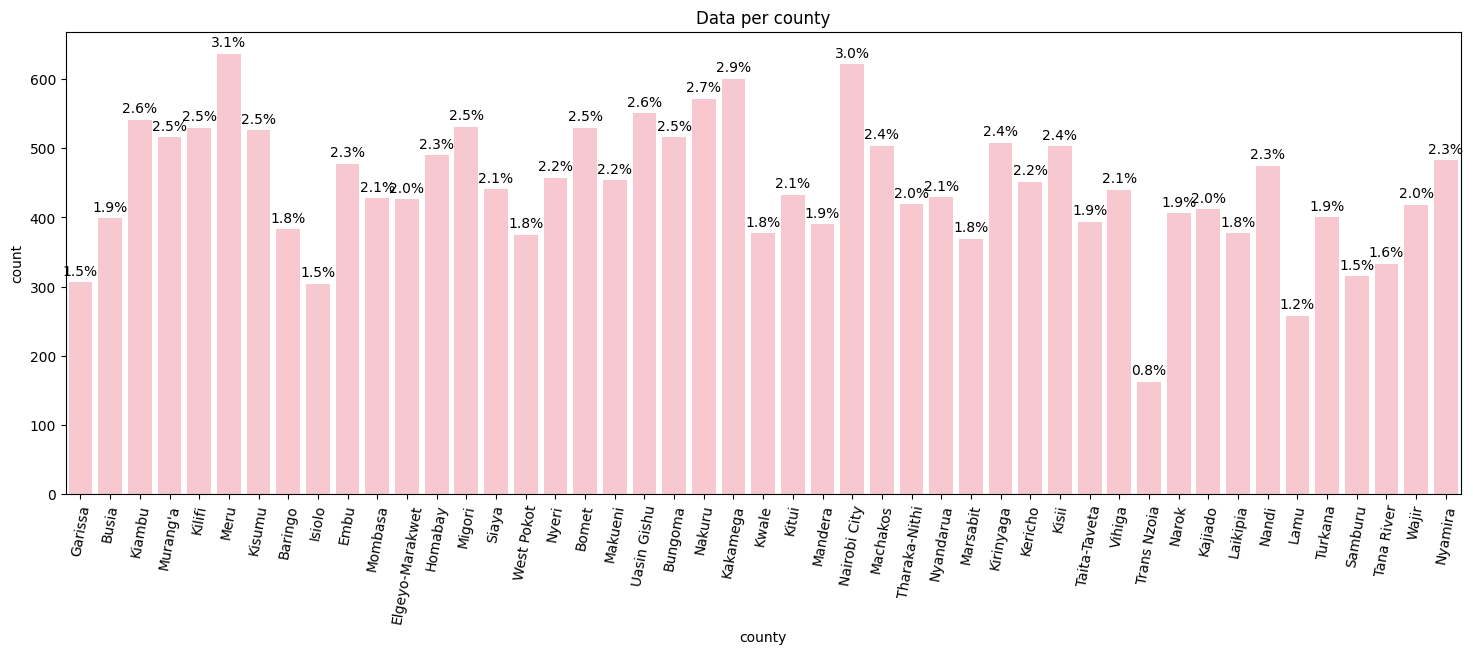

In [60]:
plt.figure(figsize=(18,6))
ax = sns.countplot(data=df,x="county",color="pink")

total_cells =len(df)

for container in ax.containers:
    # Calculate percentages: (height of bar / total rows) * 100
    labels = [f'{(h / total_cells) * 100:.1f}%' if h > 0 else '' for h in container.datavalues]

    # Stick the labels right on top of the bars!
    ax.bar_label(container, labels=labels, label_type='edge', padding=3)

plt.xticks(rotation=80)

plt.title("Data per county")

Text(0.5, 1.0, 'Education Levels')

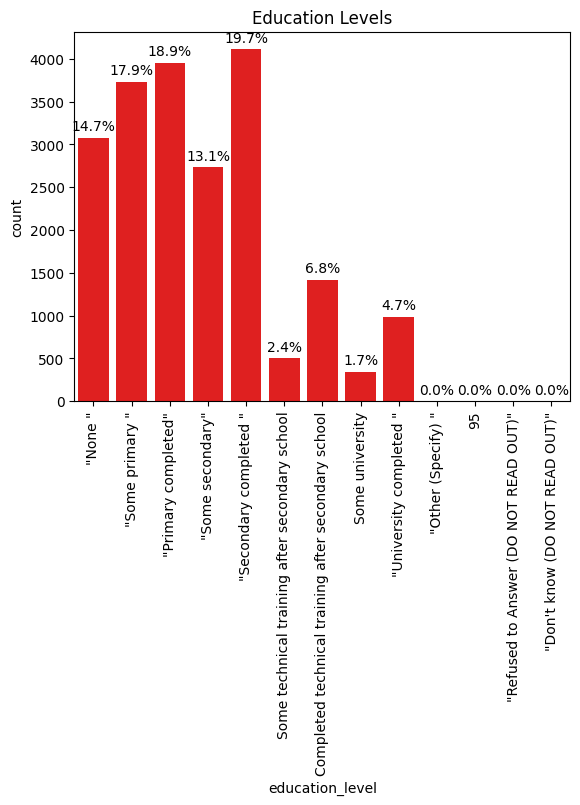

In [61]:
custom_order = ['"None "',
                '"Some primary "',
                '"Primary completed"',
                '"Some secondary"',
                '"Secondary completed "',
                'Some technical training after secondary school',
                "Completed technical training after secondary school",
                "Some university",
                '"University completed "',
                '"Other (Specify) "',
                "95",
                '"Refused to Answer (DO NOT READ OUT)"',
                '"Don\'t know (DO NOT READ OUT)"']
ax = sns.countplot(data=df,x="education_level",order=custom_order,color="red")

total_cells =len(df)

for container in ax.containers:
    # Calculate percentages: (height of bar / total rows) * 100
    labels = [f'{(h / total_cells) * 100:.1f}%' if h > 0 else '' for h in container.datavalues]

    # Stick the labels right on top of the bars!
    ax.bar_label(container, labels=labels, label_type='edge', padding=3)

plt.xticks(rotation=90)

plt.title("Education Levels")

Text(0.5, 1.0, 'Location Type')

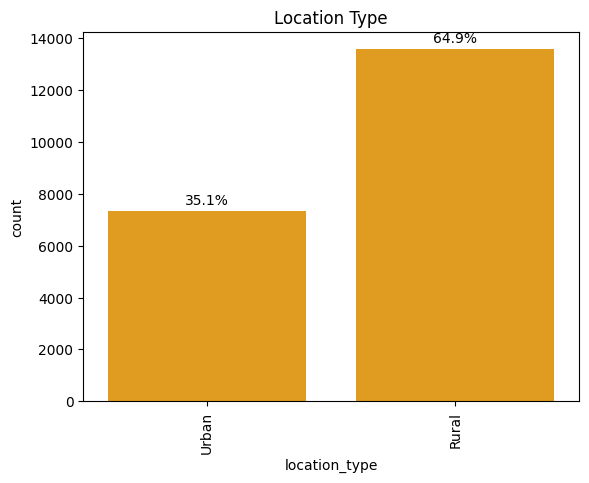

In [62]:
ax = sns.countplot(data=df,x="location_type",color="orange")

total_cells =len(df)

for container in ax.containers:
    # Calculate percentages: (height of bar / total rows) * 100
    labels = [f'{(h / total_cells) * 100:.1f}%' if h > 0 else '' for h in container.datavalues]

    # Stick the labels right on top of the bars!
    ax.bar_label(container, labels=labels, label_type='edge', padding=3)

plt.xticks(rotation=90)

plt.title("Location Type")

Text(0.5, 1.0, 'Education Levels')

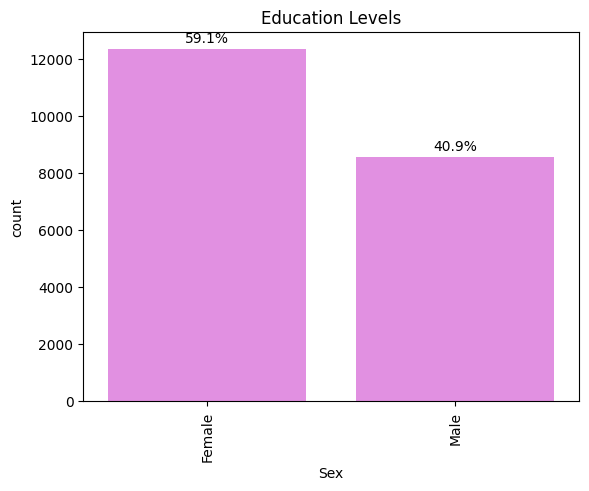

In [63]:
ax = sns.countplot(data=df,x="Sex",color="violet")

total_cells =len(df)

for container in ax.containers:
    # Calculate percentages: (height of bar / total rows) * 100
    labels = [f'{(h / total_cells) * 100:.1f}%' if h > 0 else '' for h in container.datavalues]

    # Stick the labels right on top of the bars!
    ax.bar_label(container, labels=labels, label_type='edge', padding=3)

plt.xticks(rotation=90)

plt.title("Education Levels")

Text(0.5, 1.0, 'Household Size')

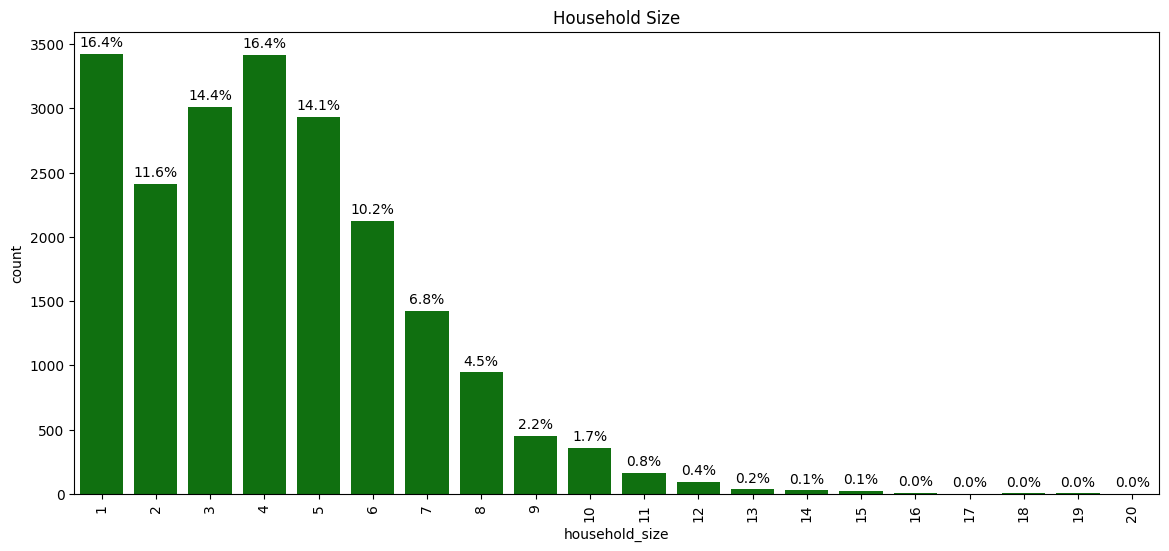

In [64]:
plt.figure(figsize=(14,6))
ax = sns.countplot(data=df,x="household_size",color="green")

total_cells =len(df)

for container in ax.containers:
    # Calculate percentages: (height of bar / total rows) * 100
    labels = [f'{(h / total_cells) * 100:.1f}%' if h > 0 else '' for h in container.datavalues]

    # Stick the labels right on top of the bars!
    ax.bar_label(container, labels=labels, label_type='edge', padding=3)

plt.xticks(rotation=90)

plt.title("Household Size")

Text(0.5, 1.0, 'Marital Status')

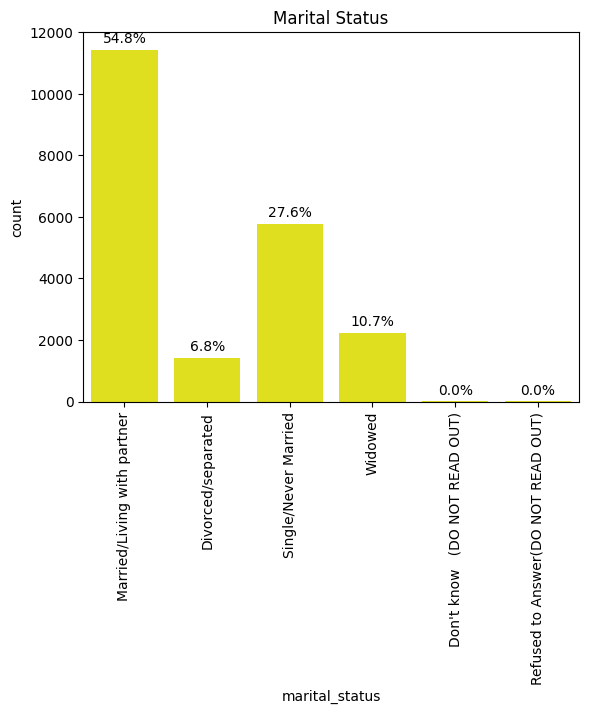

In [65]:
ax = sns.countplot(data=df,x="marital_status",color="yellow")

total_cells =len(df)

for container in ax.containers:
    # Calculate percentages: (height of bar / total rows) * 100
    labels = [f'{(h / total_cells) * 100:.1f}%' if h > 0 else '' for h in container.datavalues]

    # Stick the labels right on top of the bars!
    ax.bar_label(container, labels=labels, label_type='edge', padding=3)

plt.xticks(rotation=90)

plt.title("Marital Status")

Text(0.5, 1.0, 'Uses formal methods to save')

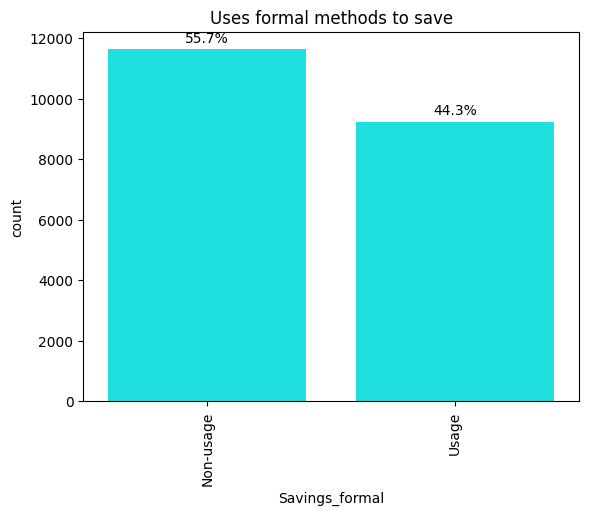

In [66]:
ax = sns.countplot(data=df,x="Savings_formal",color="cyan")

total_cells =len(df)

for container in ax.containers:
    # Calculate percentages: (height of bar / total rows) * 100
    labels = [f'{(h / total_cells) * 100:.1f}%' if h > 0 else '' for h in container.datavalues]

    # Stick the labels right on top of the bars!
    ax.bar_label(container, labels=labels, label_type='edge', padding=3)

plt.xticks(rotation=90)

plt.title("Uses formal methods to save")

Text(0.5, 1.0, 'Uses informal methods to save')

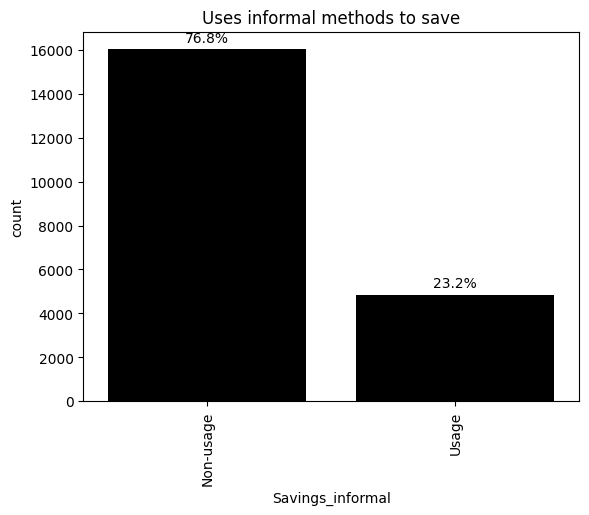

In [67]:
ax = sns.countplot(data=df,x="Savings_informal",color="black")

total_cells =len(df)

for container in ax.containers:
    # Calculate percentages: (height of bar / total rows) * 100
    labels = [f'{(h / total_cells) * 100:.1f}%' if h > 0 else '' for h in container.datavalues]

    # Stick the labels right on top of the bars!
    ax.bar_label(container, labels=labels, label_type='edge', padding=3)

plt.xticks(rotation=90)

plt.title("Uses informal methods to save")

Text(0.5, 1.0, 'Has an informal loan')

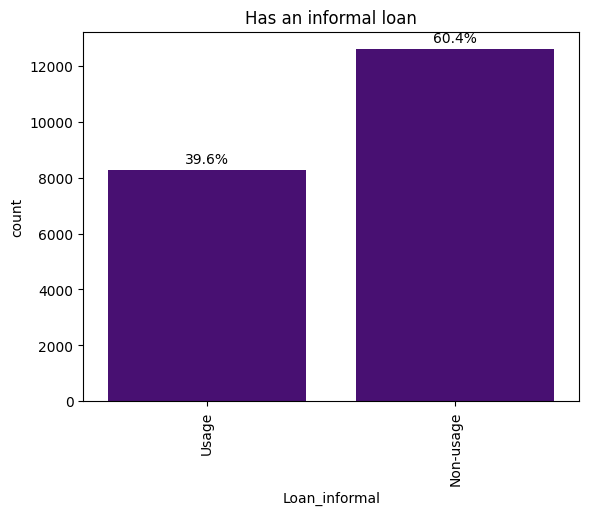

In [68]:
ax = sns.countplot(data=df,x="Loan_informal",color="indigo")

total_cells =len(df)

for container in ax.containers:
    # Calculate percentages: (height of bar / total rows) * 100
    labels = [f'{(h / total_cells) * 100:.1f}%' if h > 0 else '' for h in container.datavalues]

    # Stick the labels right on top of the bars!
    ax.bar_label(container, labels=labels, label_type='edge', padding=3)

plt.xticks(rotation=90)

plt.title("Has an informal loan")

Text(0.5, 1.0, 'Has a formal laon')

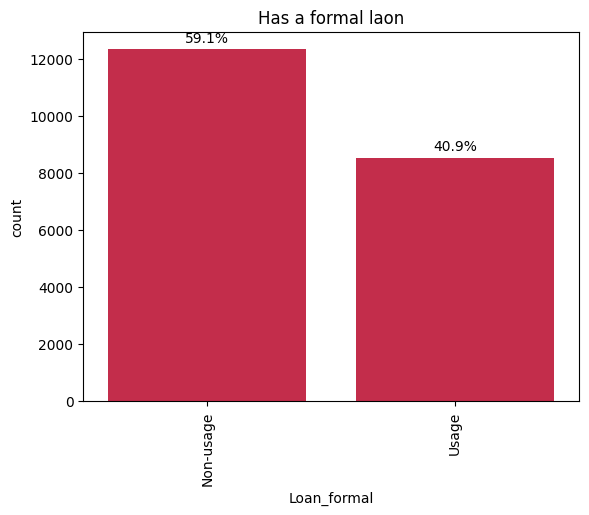

In [69]:
ax = sns.countplot(data=df,x="Loan_formal",color="crimson")

total_cells =len(df)

for container in ax.containers:
    # Calculate percentages: (height of bar / total rows) * 100
    labels = [f'{(h / total_cells) * 100:.1f}%' if h > 0 else '' for h in container.datavalues]

    # Stick the labels right on top of the bars!
    ax.bar_label(container, labels=labels, label_type='edge', padding=3)

plt.xticks(rotation=90)

plt.title("Has a formal laon")

Text(0.5, 1.0, 'Has Defaulted on a loan or debt')

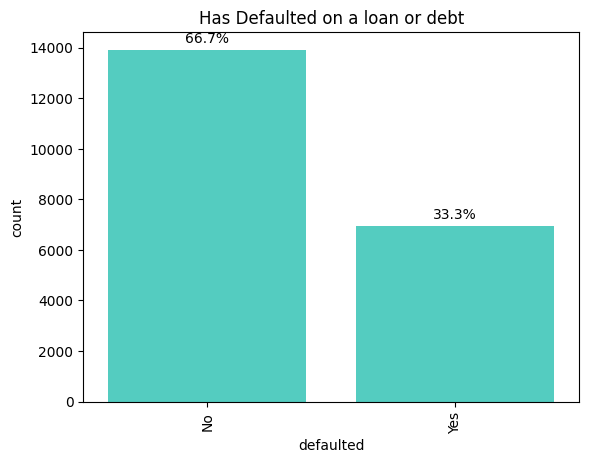

In [70]:
ax = sns.countplot(data=df,x="defaulted",color="turquoise")

total_cells =len(df)

for container in ax.containers:
    # Calculate percentages: (height of bar / total rows) * 100
    labels = [f'{(h / total_cells) * 100:.1f}%' if h > 0 else '' for h in container.datavalues]

    # Stick the labels right on top of the bars!
    ax.bar_label(container, labels=labels, label_type='edge', padding=3)

plt.xticks(rotation=90)

plt.title("Has Defaulted on a loan or debt")

Text(0.5, 1.0, 'Use of Formal Financial Services')

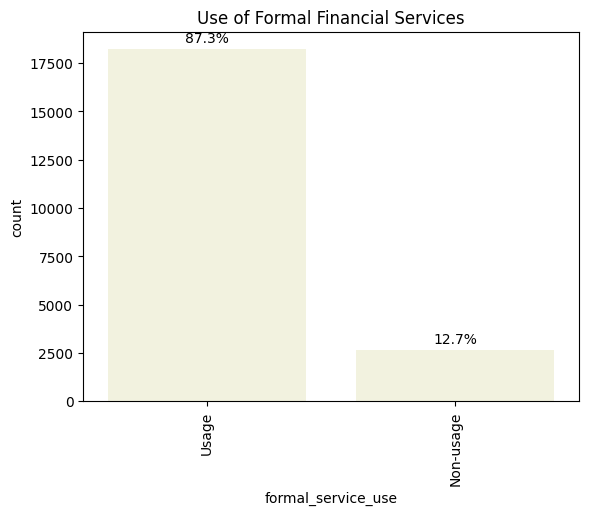

In [71]:
ax = sns.countplot(data=df,x="formal_service_use",color="beige")

total_cells =len(df)

for container in ax.containers:
    # Calculate percentages: (height of bar / total rows) * 100
    labels = [f'{(h / total_cells) * 100:.1f}%' if h > 0 else '' for h in container.datavalues]

    # Stick the labels right on top of the bars!
    ax.bar_label(container, labels=labels, label_type='edge', padding=3)

plt.xticks(rotation=90)

plt.title("Use of Formal Financial Services")

Text(0.5, 1.0, 'Mobile Money Access')

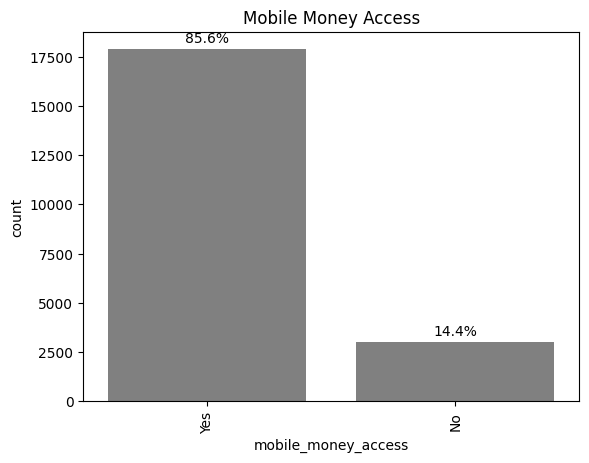

In [72]:
ax = sns.countplot(data=df,x="mobile_money_access",color="grey")

total_cells =len(df)

for container in ax.containers:
    # Calculate percentages: (height of bar / total rows) * 100
    labels = [f'{(h / total_cells) * 100:.1f}%' if h > 0 else '' for h in container.datavalues]

    # Stick the labels right on top of the bars!
    ax.bar_label(container, labels=labels, label_type='edge', padding=3)

plt.xticks(rotation=90)

plt.title("Mobile Money Access")

Text(0.5, 1.0, 'Barriers to accessing mobile money services')

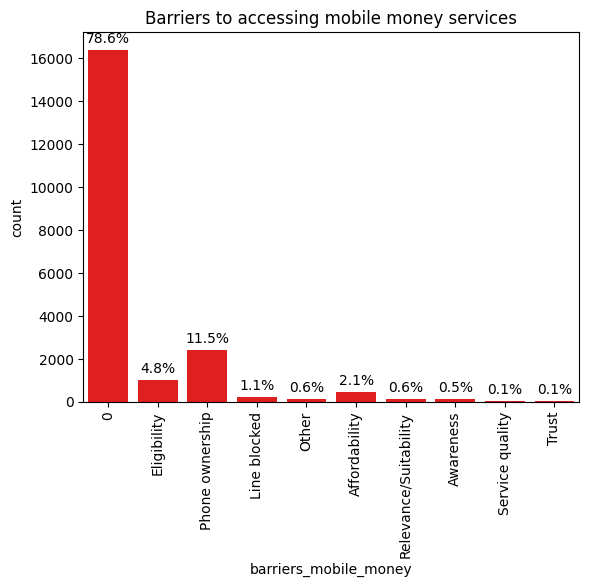

In [73]:
ax = sns.countplot(data=df,x="barriers_mobile_money",color="red")

total_cells =len(df)

for container in ax.containers:
    # Calculate percentages: (height of bar / total rows) * 100
    labels = [f'{(h / total_cells) * 100:.1f}%' if h > 0 else '' for h in container.datavalues]

    # Stick the labels right on top of the bars!
    ax.bar_label(container, labels=labels, label_type='edge', padding=3)

plt.xticks(rotation=90)

plt.title("Barriers to accessing mobile money services")

Text(0.5, 1.0, 'Owns a mobile phone')

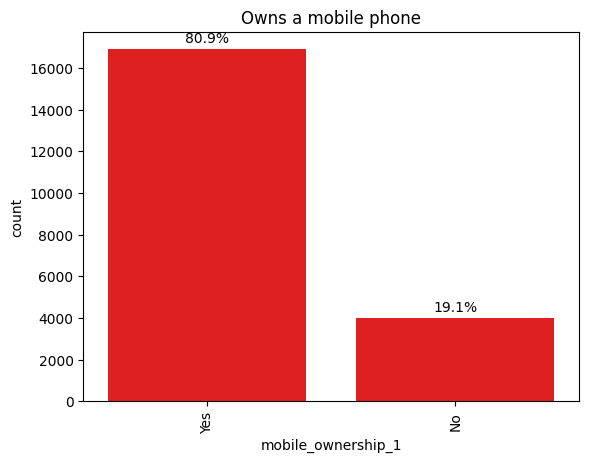

In [74]:
ax = sns.countplot(data=df,x="mobile_ownership_1",color="red")

total_cells =len(df)

for container in ax.containers:
    # Calculate percentages: (height of bar / total rows) * 100
    labels = [f'{(h / total_cells) * 100:.1f}%' if h > 0 else '' for h in container.datavalues]

    # Stick the labels right on top of the bars!
    ax.bar_label(container, labels=labels, label_type='edge', padding=3)

plt.xticks(rotation=90)

plt.title("Owns a mobile phone")

Text(0.5, 1.0, 'Experienced a financial shock in the past year')

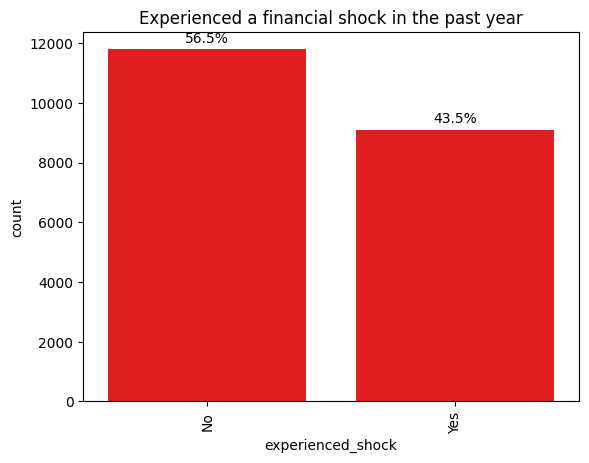

In [75]:
ax = sns.countplot(data=df,x="experienced_shock",color="red")

total_cells =len(df)

for container in ax.containers:
    # Calculate percentages: (height of bar / total rows) * 100
    labels = [f'{(h / total_cells) * 100:.1f}%' if h > 0 else '' for h in container.datavalues]

    # Stick the labels right on top of the bars!
    ax.bar_label(container, labels=labels, label_type='edge', padding=3)

plt.xticks(rotation=90)

plt.title("Experienced a financial shock in the past year")

Text(0.5, 1.0, 'Was Food Secure in past 12 months')

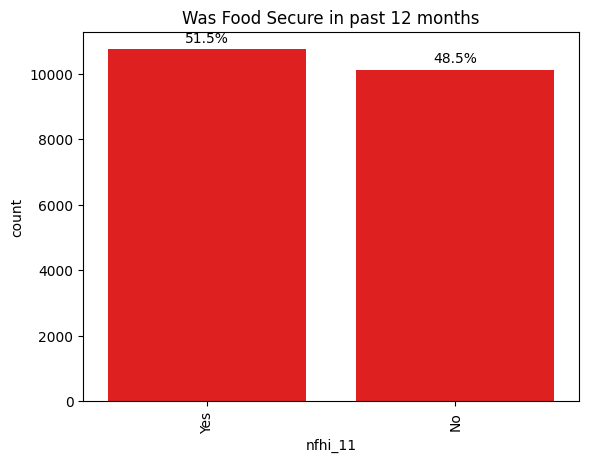

In [76]:
ax = sns.countplot(data=df,x="nfhi_11",color="red")

total_cells =len(df)

for container in ax.containers:
    # Calculate percentages: (height of bar / total rows) * 100
    labels = [f'{(h / total_cells) * 100:.1f}%' if h > 0 else '' for h in container.datavalues]

    # Stick the labels right on top of the bars!
    ax.bar_label(container, labels=labels, label_type='edge', padding=3)

plt.xticks(rotation=90)

plt.title("Was Food Secure in past 12 months")

Text(0.5, 1.0, 'Managed Non Food Spending Adequately')

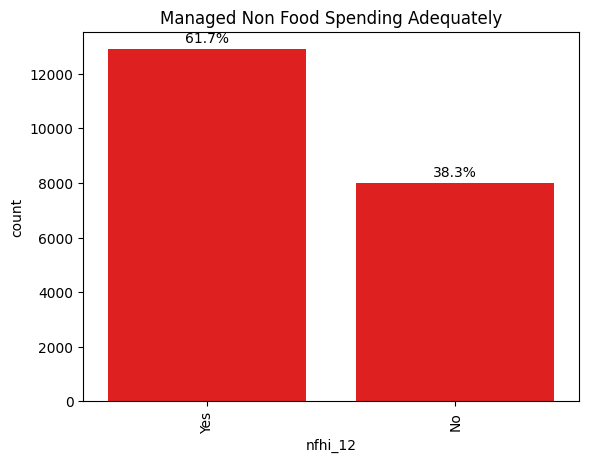

In [77]:
ax = sns.countplot(data=df,x="nfhi_12",color="red")

total_cells =len(df)

for container in ax.containers:
    # Calculate percentages: (height of bar / total rows) * 100
    labels = [f'{(h / total_cells) * 100:.1f}%' if h > 0 else '' for h in container.datavalues]

    # Stick the labels right on top of the bars!
    ax.bar_label(container, labels=labels, label_type='edge', padding=3)

plt.xticks(rotation=90)

plt.title("Managed Non Food Spending Adequately")

Text(0.5, 1.0, 'No debt stress in past 3 months')

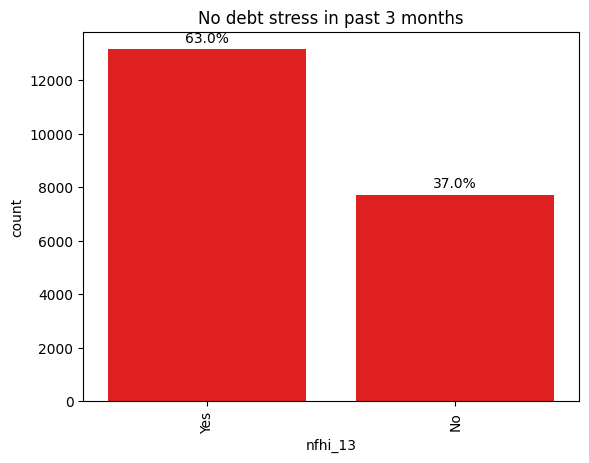

In [78]:
ax = sns.countplot(data=df,x="nfhi_13",color="red")

total_cells =len(df)

for container in ax.containers:
    # Calculate percentages: (height of bar / total rows) * 100
    labels = [f'{(h / total_cells) * 100:.1f}%' if h > 0 else '' for h in container.datavalues]

    # Stick the labels right on top of the bars!
    ax.bar_label(container, labels=labels, label_type='edge', padding=3)

plt.xticks(rotation=90)

plt.title("No debt stress in past 3 months")

Text(0.5, 1.0, 'Access to emergency 13K in 1 month')

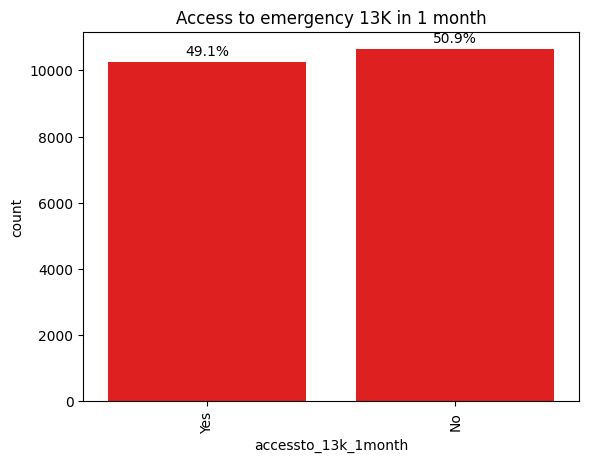

In [79]:
ax = sns.countplot(data=df,x="accessto_13k_1month",color="red")

total_cells =len(df)

for container in ax.containers:
    # Calculate percentages: (height of bar / total rows) * 100
    labels = [f'{(h / total_cells) * 100:.1f}%' if h > 0 else '' for h in container.datavalues]

    # Stick the labels right on top of the bars!
    ax.bar_label(container, labels=labels, label_type='edge', padding=3)

plt.xticks(rotation=90)

plt.title("Access to emergency 13K in 1 month")

Text(0.5, 1.0, 'Emergency Funds not difficult to find in 30 days')

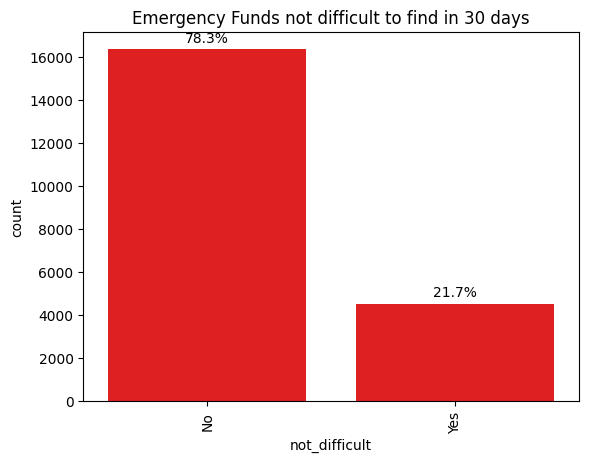

In [80]:
ax = sns.countplot(data=df,x="not_difficult",color="red")

total_cells =len(df)

for container in ax.containers:
    # Calculate percentages: (height of bar / total rows) * 100
    labels = [f'{(h / total_cells) * 100:.1f}%' if h > 0 else '' for h in container.datavalues]

    # Stick the labels right on top of the bars!
    ax.bar_label(container, labels=labels, label_type='edge', padding=3)

plt.xticks(rotation=90)

plt.title("Emergency Funds not difficult to find in 30 days")

Text(0.5, 1.0, 'Financial Status after access to mobile money ')

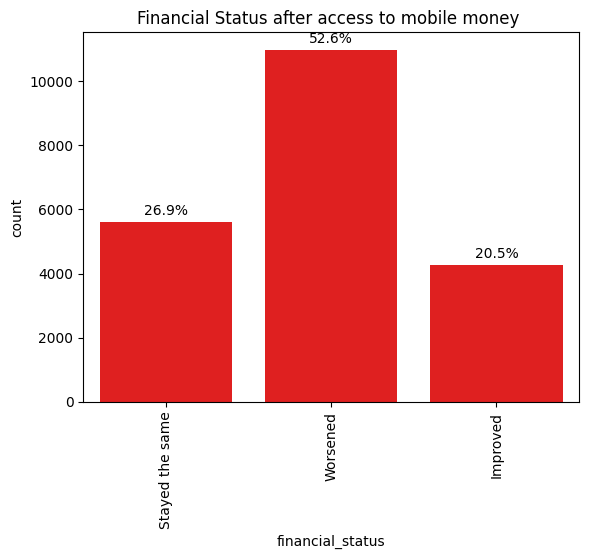

In [81]:
ax = sns.countplot(data=df,x="financial_status",color="red")

total_cells =len(df)

for container in ax.containers:
    # Calculate percentages: (height of bar / total rows) * 100
    labels = [f'{(h / total_cells) * 100:.1f}%' if h > 0 else '' for h in container.datavalues]

    # Stick the labels right on top of the bars!
    ax.bar_label(container, labels=labels, label_type='edge', padding=3)

plt.xticks(rotation=90)

plt.title("Financial Status after access to mobile money ")

Text(0.5, 1.0, 'Financial Literacy Score')

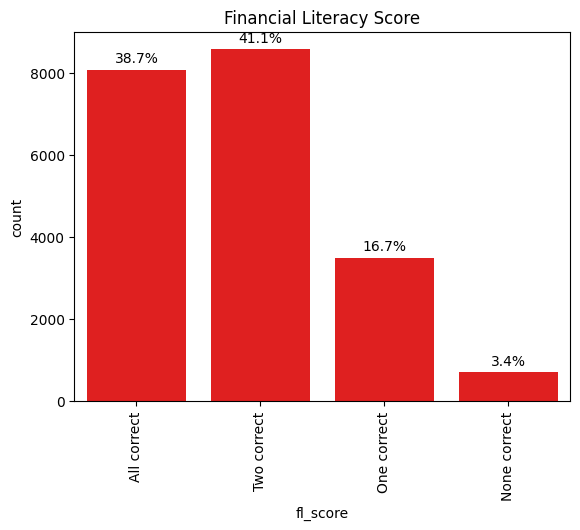

In [82]:
ax = sns.countplot(data=df,x="fl_score",color="red")

total_cells =len(df)

for container in ax.containers:
    # Calculate percentages: (height of bar / total rows) * 100
    labels = [f'{(h / total_cells) * 100:.1f}%' if h > 0 else '' for h in container.datavalues]

    # Stick the labels right on top of the bars!
    ax.bar_label(container, labels=labels, label_type='edge', padding=3)

plt.xticks(rotation=90)

plt.title("Financial Literacy Score")

Text(0.5, 1.0, 'Number of Financial Products Used')

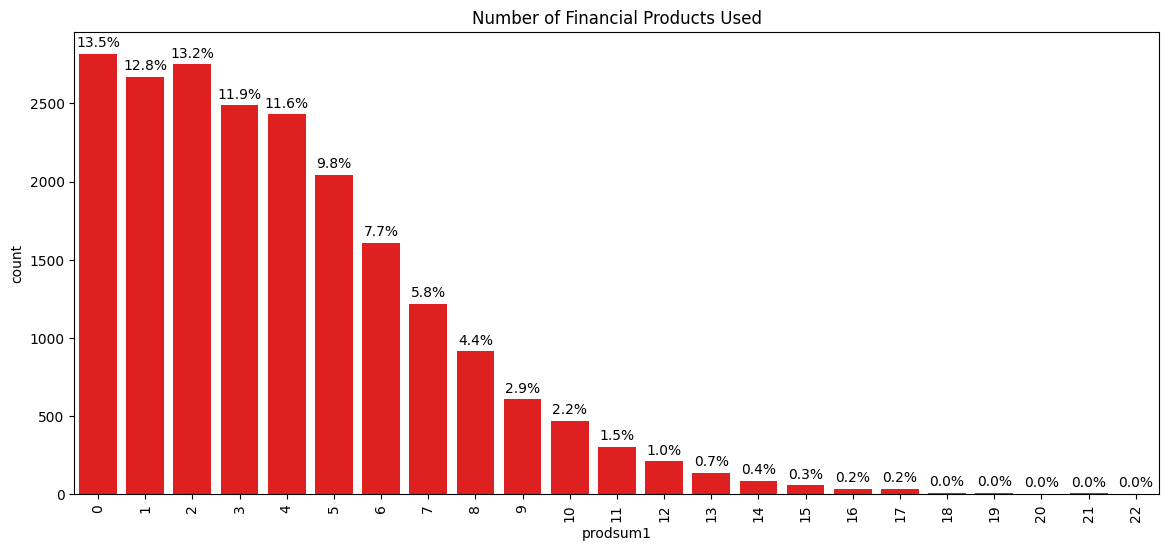

In [83]:
plt.figure(figsize=(14,6))
ax = sns.countplot(data=df,x="prodsum1",color="red")

total_cells =len(df)

for container in ax.containers:
    # Calculate percentages: (height of bar / total rows) * 100
    labels = [f'{(h / total_cells) * 100:.1f}%' if h > 0 else '' for h in container.datavalues]

    # Stick the labels right on top of the bars!
    ax.bar_label(container, labels=labels, label_type='edge', padding=3)

plt.xticks(rotation=90)

plt.title("Number of Financial Products Used")

Text(0.5, 1.0, 'Barriers to Accessing Bank services')

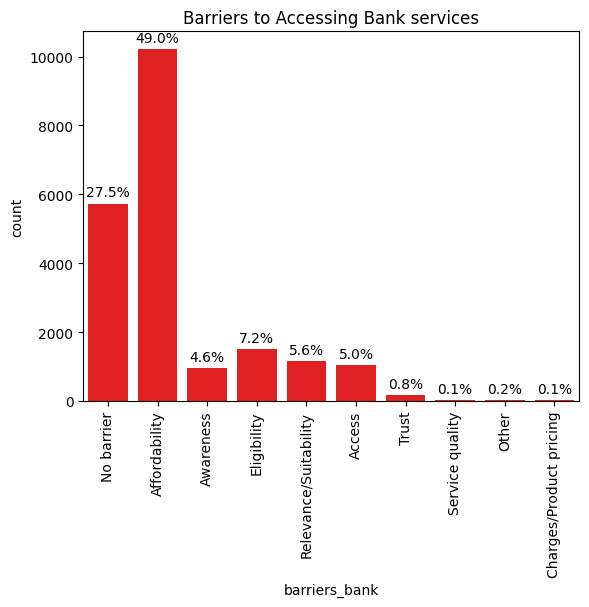

In [84]:
ax = sns.countplot(data=df,x="barriers_bank",color="red")
total_cells =len(df)

for container in ax.containers:
    # Calculate percentages: (height of bar / total rows) * 100
    labels = [f'{(h / total_cells) * 100:.1f}%' if h > 0 else '' for h in container.datavalues]

    # Stick the labels right on top of the bars!
    ax.bar_label(container, labels=labels, label_type='edge', padding=3)

plt.xticks(rotation=90)

plt.title("Barriers to Accessing Bank services")

Text(0.5, 1.0, 'Has Disability')

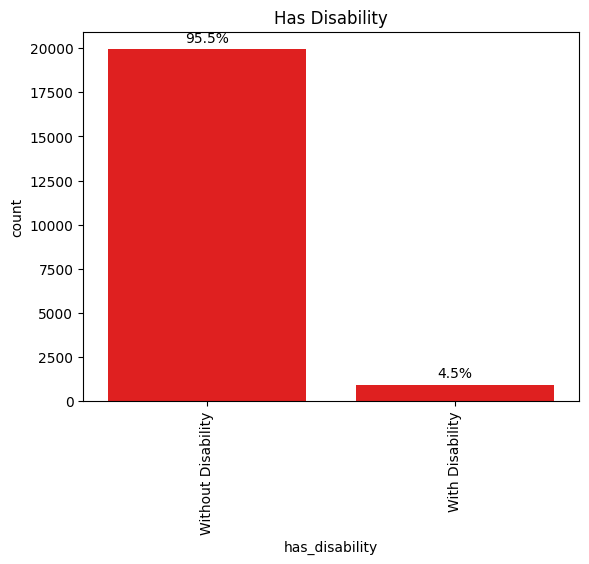

In [85]:
ax = sns.countplot(data=df,x="has_disability",color="red")

total_cells =len(df)

for container in ax.containers:
    # Calculate percentages: (height of bar / total rows) * 100
    labels = [f'{(h / total_cells) * 100:.1f}%' if h > 0 else '' for h in container.datavalues]

    # Stick the labels right on top of the bars!
    ax.bar_label(container, labels=labels, label_type='edge', padding=3)

plt.xticks(rotation=90)

plt.title("Has Disability")

Section 5: Data Cleaning

All of these gropuings have less than 1% contribution to the data, even when grouped

*   Group all people with financial products > 10 to one group
*   Drop all tuples with the following education values:
      * 95
      * Refused to answer
      * Don't know
*   Group all Households which are >=12
*   Drop all marital status tuples that have the following values:
      * Refused to answer
      * Don't know


Major inclusion

*   We argue that if someone has food security issues (nfhi_11), access to mobile money or fintech services is less likely to play a role in their financial status because they are already in a very poor financial situation and are likely to only improve.
* However to allow the data to map to portions of the population that are food insecure we have included the field.



In [86]:
df['prodsum1'] = df['prodsum1'].replace({11:'>10',12:'>10',13:'>10',14:'>10',15:'>10',16:'>10',17:'>10',18:'>10',19:'>10',20:'>10',21:'>10',22:'>10'})

Text(0.5, 1.0, 'Household Size')

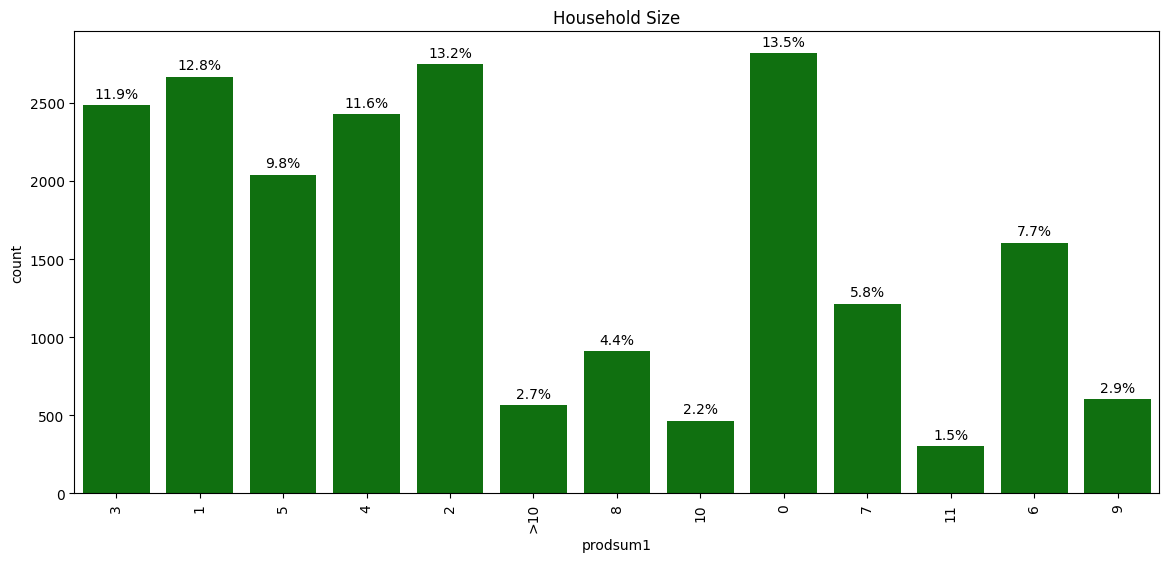

In [87]:
plt.figure(figsize=(14,6))
ax = sns.countplot(data=df,x="prodsum1",color="green")

total_cells =len(df)

for container in ax.containers:
    # Calculate percentages: (height of bar / total rows) * 100
    labels = [f'{(h / total_cells) * 100:.1f}%' if h > 0 else '' for h in container.datavalues]

    # Stick the labels right on top of the bars!
    ax.bar_label(container, labels=labels, label_type='edge', padding=3)

plt.xticks(rotation=90)

plt.title("Household Size")

In [88]:
df = df[df['education_level']!='"Other (Specify) "']
df = df[df['education_level']!=95]
df = df[df['education_level']!='"Refused to Answer (DO NOT READ OUT)"']
df = df[df['education_level']!='"Don\'t know (DO NOT READ OUT)"']

print(df['education_level'].unique())

['Completed technical training after secondary school' '"None "'
 '"Primary completed"' '"Some secondary"'
 'Some technical training after secondary school' '"Secondary completed "'
 '"Some primary "' '"University completed "' 'Some university']


In [89]:
df['household_size'] = df['household_size'].replace({12:'>10',13:'>10',14:'>10',15:'>10',16:'>10',17:'>10',18:'>10',19:'>10',20:'>10',21:'>10',22:'>10'})
df['household_size'] = df['household_size'].replace('>10','>11')

print(df['household_size'].unique())

[5 11 2 1 3 6 7 4 10 8 9 '>11']


Text(0.5, 1.0, 'Household Size')

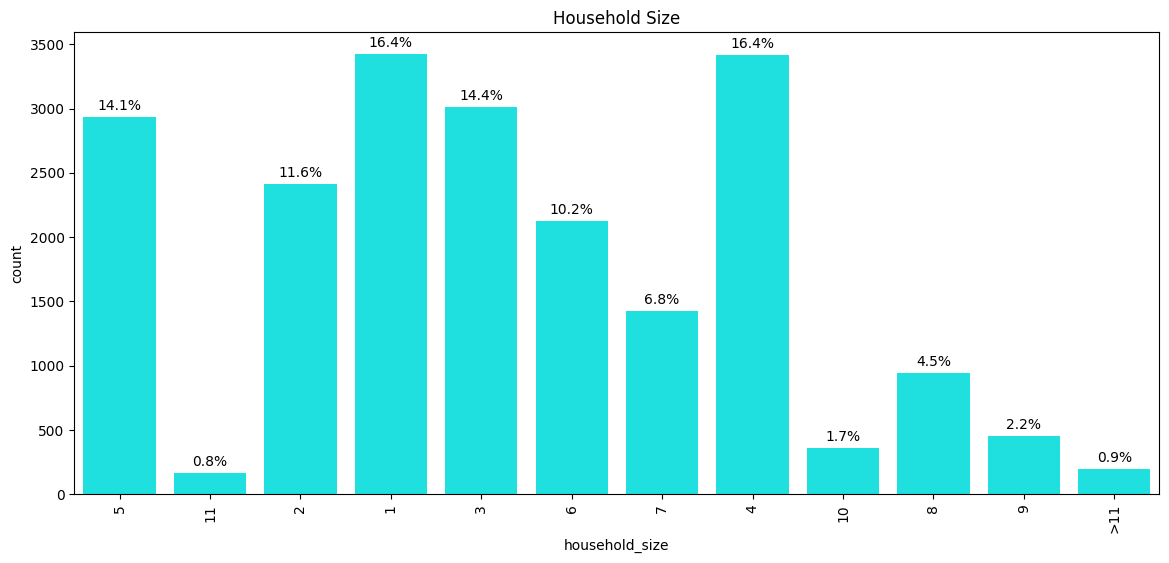

In [90]:
plt.figure(figsize=(14,6))
ax = sns.countplot(data=df,x="household_size",color="cyan")

total_cells =len(df)

for container in ax.containers:
    # Calculate percentages: (height of bar / total rows) * 100
    labels = [f'{(h / total_cells) * 100:.1f}%' if h > 0 else '' for h in container.datavalues]

    # Stick the labels right on top of the bars!
    ax.bar_label(container, labels=labels, label_type='edge', padding=3)

plt.xticks(rotation=90)

plt.title("Household Size")

In [91]:
df = df[df['marital_status']!='Refused to Answer(DO NOT READ OUT)']
df = df[df['marital_status']!='Don\'t know   (DO NOT READ OUT)']

print(df['marital_status'].unique())

['Married/Living with partner' 'Divorced/separated' 'Single/Never Married'
 'Widowed']


In [ ]:
df['education_level'] = df['education_level'].replace({})
df['education_level'] = df['education_level'].replace('>10','>11')

print(df['education_level'].unique())

# Section 5.5 Data Cleaning Post Model Changes:

### Post training the model the first time, r^2 = 0.11 which was not good.
*  To ensure a better fit, we grouped counties into regions.

<br>

 ### Post training number 3, columns were still too many.
*  Reduced education level to become Primary and Below, Secondary and Below, Tertiary, Dropped Other
*  Reduced Household size to become 1 - 6, 6 - 11 and >11
*  Reduced Financial Product usage to become 0-5,5-11 and >11


In [106]:
kenya_county_to_province = {
    # Coast Province
    'Mombasa': 'Coast', 'Kwale': 'Coast', 'Kilifi': 'Coast',
    'Tana River': 'Coast', 'Lamu': 'Coast', 'Taita Taveta': 'Coast',
    'Taita-Taveta': 'Coast',  # Accounted for alternative hyphenation

    # North Eastern Province
    'Garissa': 'North Eastern', 'Wajir': 'North Eastern', 'Mandera': 'North Eastern',

    # Eastern Province
    'Marsabit': 'Eastern', 'Isiolo': 'Eastern', 'Meru': 'Eastern',
    'Tharaka Nithi': 'Eastern', 'Tharaka-Nithi': 'Eastern', 'Embu': 'Eastern',
    'Kitui': 'Eastern', 'Machakos': 'Eastern', 'Makueni': 'Eastern',

    # Central Province
    'Nyandarua': 'Central', 'Nyeri': 'Central', 'Kirinyaga': 'Central',
    'Murang\'a': 'Central', 'Kiambu': 'Central',

    # Rift Valley Province
    'Turkana': 'Rift Valley', 'West Pokot': 'Rift Valley', 'Samburu': 'Rift Valley',
    'Trans Nzoia': 'Rift Valley', 'Trans-Nzoia': 'Rift Valley', 'Uasin Gishu': 'Rift Valley',
    'Elgeyo Marakwet': 'Rift Valley', 'Elgeyo-Marakwet': 'Rift Valley', 'Nandi': 'Rift Valley',
    'Baringo': 'Rift Valley', 'Laikipia': 'Rift Valley', 'Nakuru': 'Rift Valley',
    'Narok': 'Rift Valley', 'Kajiado': 'Rift Valley', 'Kericho': 'Rift Valley', 'Bomet': 'Rift Valley',

    # Western Province
    'Kakamega': 'Western', 'Vihiga': 'Western', 'Bungoma': 'Western', 'Busia': 'Western',

    # Nyanza Province
    'Siaya': 'Nyanza', 'Kisumu': 'Nyanza', 'Homabay': 'Nyanza',
    'Migori': 'Nyanza', 'Kisii': 'Nyanza', 'Nyamira': 'Nyanza',

    # Nairobi Province
    'Nairobi': 'Nairobi', 'Nairobi City': 'Nairobi'
}

df['Region'] = df['county'].map(kenya_county_to_province).fillna('Other')

# Drop the old 'County' column so the model doesn't use it anymore
df = df.drop('county', axis=1)

print(df['Region'].unique())

['North Eastern' 'Western' 'Central' 'Coast' 'Eastern' 'Nyanza'
 'Rift Valley' 'Nairobi']


Text(0.5, 1.0, 'Data per Region')

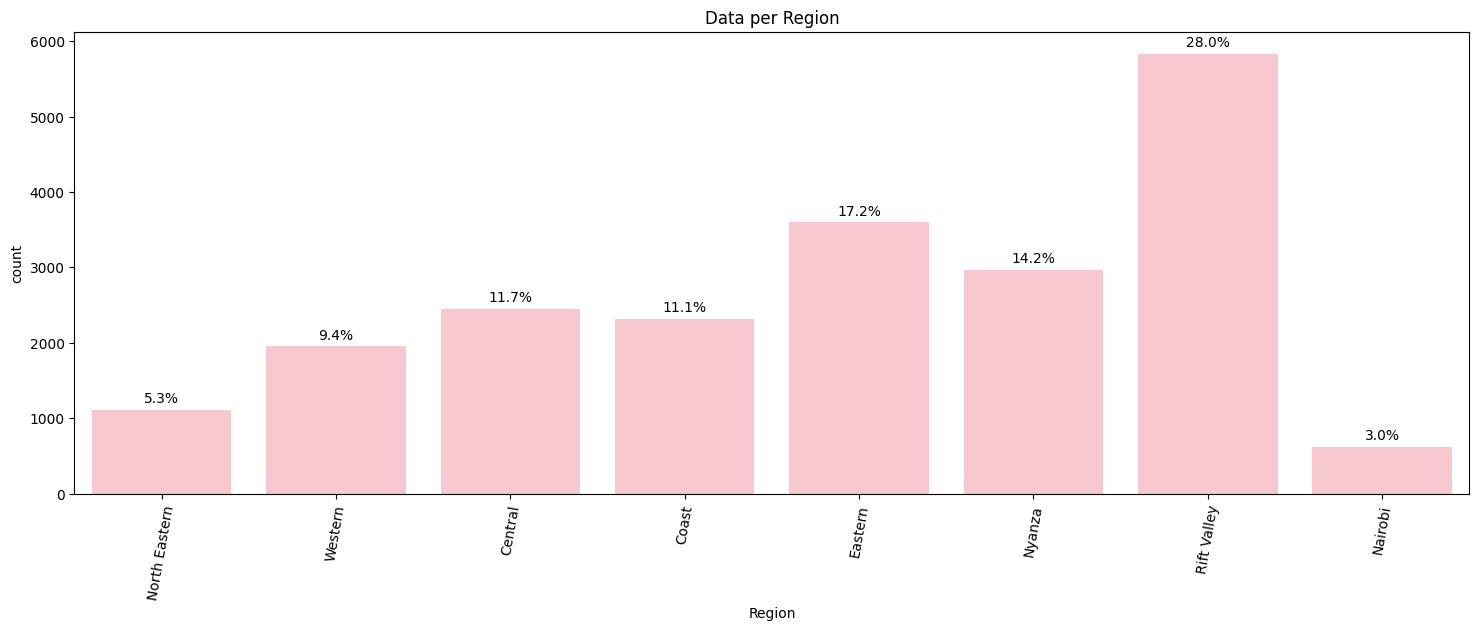

In [107]:
plt.figure(figsize=(18,6))
ax = sns.countplot(data=df,x="Region",color="pink")

total_cells =len(df)

for container in ax.containers:
    # Calculate percentages: (height of bar / total rows) * 100
    labels = [f'{(h / total_cells) * 100:.1f}%' if h > 0 else '' for h in container.datavalues]

    # Stick the labels right on top of the bars!
    ax.bar_label(container, labels=labels, label_type='edge', padding=3)

plt.xticks(rotation=80)

plt.title("Data per Region")

['Tertiary & Above' '"None "' 'Primary & Below' 'Secondary & Below'
 'Some university']


Text(0.5, 1.0, 'Education Levels')

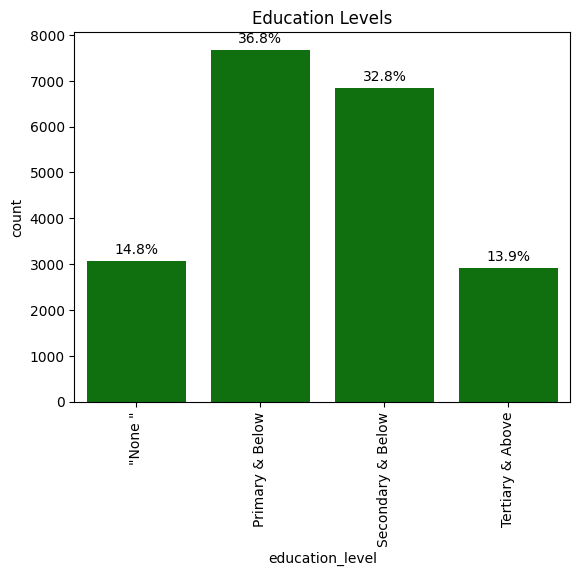

In [125]:
df['education_level'] = df['education_level'].replace({'"Some primary "':'Primary & Below','"Primary completed"':'Primary & Below'})
df['education_level'] = df['education_level'].replace({'"Some secondary"':'Secondary & Below','"Secondary completed "':'Secondary & Below'})
df['education_level'] = df['education_level'].replace({'Some technical training after secondary school':'Tertiary & Above',"Completed technical training after secondary school":'Tertiary & Above'})
df['education_level'] = df['education_level'].replace({'"University completed "':'Tertiary & Above',"Completed technical training after secondary school":'Tertiary & Above'})

print(df['education_level'].unique())

custom_order = ['"None "',
                'Primary & Below',
                'Secondary & Below',
                "Tertiary & Above",
                ]
ax = sns.countplot(data=df,x="education_level",order=custom_order,color="green")

total_cells =len(df)

for container in ax.containers:
    # Calculate percentages: (height of bar / total rows) * 100
    labels = [f'{(h / total_cells) * 100:.1f}%' if h > 0 else '' for h in container.datavalues]

    # Stick the labels right on top of the bars!
    ax.bar_label(container, labels=labels, label_type='edge', padding=3)

plt.xticks(rotation=90)

plt.title("Education Levels")

['1-6' '7-11' '>11']


Text(0.5, 1.0, 'Household Size')

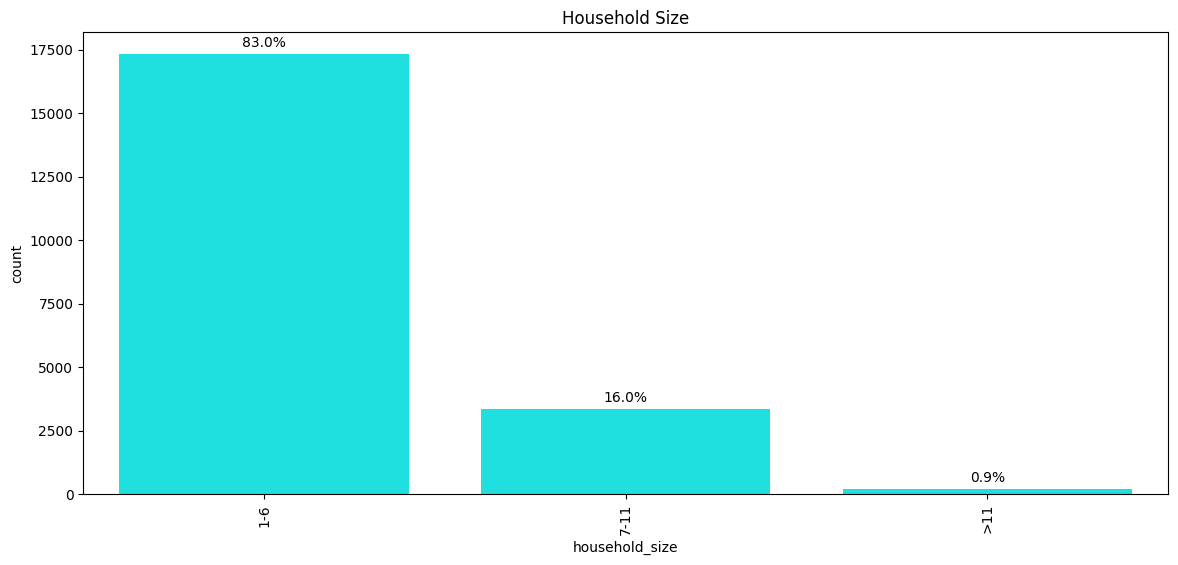

In [126]:
df['household_size'] = df['household_size'].replace({1:'1-6',2:'1-6',3:'1-6',4:'1-6',5:'1-6',6:'1-6'})
df['household_size'] = df['household_size'].replace({7:'7-11',8:'7-11',9:'7-11',10:'7-11',11:'7-11'})

print(df['household_size'].unique())

plt.figure(figsize=(14,6))
ax = sns.countplot(data=df,x="household_size",color="cyan")

total_cells =len(df)

for container in ax.containers:
    # Calculate percentages: (height of bar / total rows) * 100
    labels = [f'{(h / total_cells) * 100:.1f}%' if h > 0 else '' for h in container.datavalues]

    # Stick the labels right on top of the bars!
    ax.bar_label(container, labels=labels, label_type='edge', padding=3)

plt.xticks(rotation=90)

plt.title("Household Size")

['0-5' '>10' '6-11']


Text(0.5, 1.0, 'Number of Financial Products Used')

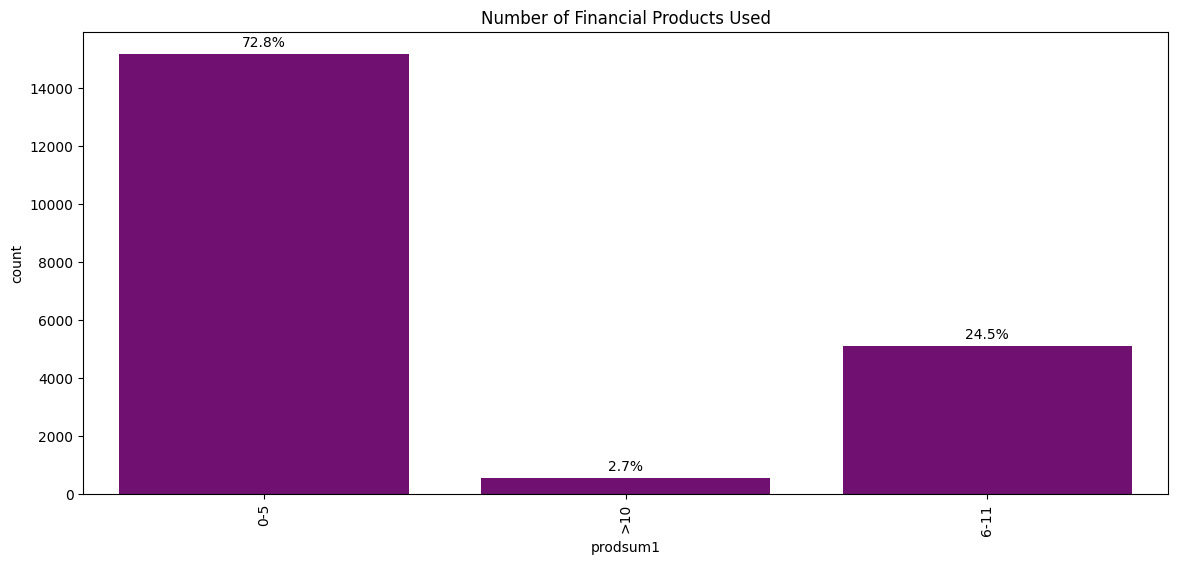

In [127]:
df['prodsum1'] = df['prodsum1'].replace({0:'0-5',1:'0-5',2:'0-5',3:'0-5',4:'0-5',5:'0-5'})
df['prodsum1'] = df['prodsum1'].replace({6:'6-11',7:'6-11',8:'6-11',9:'6-11',10:'6-11',11:'6-11'})

print(df['prodsum1'].unique())

plt.figure(figsize=(14,6))
ax = sns.countplot(data=df,x="prodsum1",color="purple")

total_cells =len(df)

for container in ax.containers:
    # Calculate percentages: (height of bar / total rows) * 100
    labels = [f'{(h / total_cells) * 100:.1f}%' if h > 0 else '' for h in container.datavalues]

    # Stick the labels right on top of the bars!
    ax.bar_label(container, labels=labels, label_type='edge', padding=3)

plt.xticks(rotation=90)

plt.title("Number of Financial Products Used")


# Section 6: Train and Split and Encode Data



In [128]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import classification_report

# Encode your target
le = LabelEncoder()
y = le.fit_transform(df['financial_status'])

X = df.drop(columns=['financial_status'])

outcome_map = {"Worsened": -1, "Stayed the same": 0, "Improved": 1}
y = df["financial_status"].map(outcome_map)

#  Encode the rest of your data

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

# Split into the validation set now
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=(15/85), random_state=42)


In [129]:
# Encode the data
categorical_columns = X.select_dtypes(include=['object','category']).columns
numerical_columns = X.select_dtypes(exclude=['object','category']).columns

print(categorical_columns)
print(numerical_columns)

Index(['location_type', 'Sex', 'Age', 'household_size', 'education_level',
       'marital_status', 'Savings_formal', 'Savings_informal', 'Loan_formal',
       'Loan_informal', 'defaulted', 'formal_service_use',
       'mobile_money_access', 'barriers_mobile_money', 'mobile_ownership_1',
       'experienced_shock', 'nfhi_11', 'nfhi_12', 'nfhi_13',
       'accessto_13k_1month', 'not_difficult', 'fl_score', 'prodsum1',
       'barriers_bank', 'has_disability', 'Region'],
      dtype='object')
Index(['monthly_income'], dtype='object')


In [130]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_columns),
        ('categorical', OneHotEncoder(handle_unknown="ignore"), categorical_columns)
    ])

X_train[categorical_columns]=X_train[categorical_columns].astype(str)
X_val[categorical_columns]=X_val[categorical_columns].astype(str)
X_test[categorical_columns]=X_test[categorical_columns].astype(str)

X_train = preprocessor.fit_transform(X_train)
X_val = preprocessor.transform(X_val)
X_test = preprocessor.transform(X_test)

In [131]:
# Verification Test
print(f"Train Shape: {X_train.shape}")
print(f"Validation Shape: {X_val.shape}")
print(f"Test Shape: {X_test.shape}")

Train Shape: (14597, 88)
Validation Shape: (3128, 88)
Test Shape: (3128, 88)


# SECTION 7: Train the data

In [136]:
# Get the list of all the columns that are there in the training data
# Rebuild the DataFrame with the correct column names
X_train_df = pd.DataFrame(X_train, columns=preprocessor.get_feature_names_out())

# Now you can use standard Pandas commands again!
print(X_train_df.columns)

Index(['num__monthly_income', 'categorical__location_type_Rural',
       'categorical__location_type_Urban', 'categorical__Sex_Female',
       'categorical__Sex_Male', 'categorical__Age_16-17',
       'categorical__Age_18-25', 'categorical__Age_26-35',
       'categorical__Age_36-45', 'categorical__Age_46-55',
       'categorical__Age_Above 55', 'categorical__household_size_1-6',
       'categorical__household_size_7-11', 'categorical__household_size_>11',
       'categorical__education_level_"None "',
       'categorical__education_level_Primary & Below',
       'categorical__education_level_Secondary & Below',
       'categorical__education_level_Some university',
       'categorical__education_level_Tertiary & Above',
       'categorical__marital_status_Divorced/separated',
       'categorical__marital_status_Married/Living with partner',
       'categorical__marital_status_Single/Never Married',
       'categorical__marital_status_Widowed',
       'categorical__Savings_formal_Non-u

In [133]:
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, max_depth=8, min_samples_leaf=5,random_state=42)
model.fit(X_train, y_train)

y_val_pred = model.predict(X_val)

print("=== Validation Performance ===")
print(f"Mean Absolute Error: {mean_absolute_error(y_val, y_val_pred):.2f}")
print(f"R-squared Score: {r2_score(y_val, y_val_pred):.2f}")

=== Validation Performance ===
Mean Absolute Error: 0.64
R-squared Score: 0.13


*   First Training -> 0.11
*   Second Training -> 0.09 (Removed Counties and Used Regions)
*   Third training -> 0.12 (Ask 8 questions max and at least 5 people in the final groups)
*   Fourth Trainind -> 0.13 (Group Education Values, Group Household numbers,Group Financial Products used)

# Section 7.1: Light GBM
*  Ran with RandomRegression and R^2 has not improved by much.
* Pivoted to Light GBM Regression

In [137]:
!pip install lightgbm

In [138]:
from lightgbm import LGBMRegressor

model = LGBMRegressor(n_estimators=200, max_depth=6, learning_rate=0.05, random_state=42)
model.fit(X_train, y_train)

y_val_pred = model.predict(X_val)

print("=== Validation Performance ===")
print(f"Mean Absolute Error: {mean_absolute_error(y_val, y_val_pred):.2f}")
print(f"R-squared Score: {r2_score(y_val, y_val_pred):.2f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007615 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 304
[LightGBM] [Info] Number of data points in the train set: 14597, number of used features: 84
[LightGBM] [Info] Start training from score -0.320545
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


# Section 7.2: Pivot to Classification

*  Rememer we are beginners 😆.
*  And we learnt a lot:
    *  If we are meant to get to 3 distinct values we should have classified rather than regressed.
    *  Regression would have been better if we were getting to a range of values.

In [141]:
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, classification_report

model = LGBMClassifier(n_estimators=200, num_leaves=31,class_weight='balanced', learning_rate=0.05, random_state=42)
model.fit(X_train, y_train)

y_val_pred = model.predict(X_val)

print("=== Validation Performance (Classification) ===")
print(f"Overall Accuracy: {accuracy_score(y_val, y_val_pred):.2f}")
print("\nDetailed Performance Report:")
print(classification_report(y_val, y_val_pred))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.025480 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 304
[LightGBM] [Info] Number of data points in the train set: 14597, number of used features: 84
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


=== Validation Performance (Classification) ===
Overall Accuracy: 0.52

Detailed Performance Report:
              precision    recall  f1-score   support

          -1       0.69      0.58      0.63      1656
           0       0.41      0.37      0.39       846
           1       0.35      0.55      0.43       626

    accuracy                           0.52      3128
   macro avg       0.48      0.50      0.48      3128
weighted avg       0.55      0.52      0.52      3128



Yay 🎊.

-> Test 1 with classification = 0.57 accuracy
-> Test 2, added the balanced = 0.52

# Section 7.2.1 Remove Encoding to Binary Digits

In [145]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import classification_report

# Encode your target
le = LabelEncoder()
y = le.fit_transform(df['financial_status'])

X = df.drop(columns=['financial_status'])

outcome_map = {"Worsened": -1, "Stayed the same": 0, "Improved": 1}
y = df["financial_status"].map(outcome_map)

#  Encode the rest of your data

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

# Split into the validation set now
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=(15/85), random_state=42)

In [146]:
# Encode the data
categorical_columns = X.select_dtypes(include=['object','category']).columns
numerical_columns = X.select_dtypes(exclude=['object','category']).columns

print(categorical_columns)
print(numerical_columns)

Index(['location_type', 'Sex', 'Age', 'household_size', 'education_level',
       'marital_status', 'Savings_formal', 'Savings_informal', 'Loan_formal',
       'Loan_informal', 'defaulted', 'formal_service_use',
       'mobile_money_access', 'barriers_mobile_money', 'mobile_ownership_1',
       'experienced_shock', 'nfhi_11', 'nfhi_12', 'nfhi_13',
       'accessto_13k_1month', 'not_difficult', 'fl_score', 'prodsum1',
       'barriers_bank', 'has_disability', 'Region'],
      dtype='object')
Index(['monthly_income'], dtype='object')


In [147]:
# Convert the columns into categorical columns
for col in categorical_columns:
    X_train[col] = X_train[col].astype('category')
    X_val[col] = X_val[col].astype('category')
    X_test[col] = X_test[col].astype('category')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_columns),
        ('cat', 'passthrough', categorical_columns)
    ])

for col in numerical_columns:
    X_train[col] = X_train[col].astype(float)
    X_val[col] = X_val[col].astype(float)
    X_test[col] = X_test[col].astype(float)


In [148]:
# Verification Test
print(f"Train Shape: {X_train.shape}")
print(f"Validation Shape: {X_val.shape}")
print(f"Test Shape: {X_test.shape}")

Train Shape: (14597, 27)
Validation Shape: (3128, 27)
Test Shape: (3128, 27)


# Section 7.2.1.REAL : Train the new model

In [150]:
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, classification_report

model = LGBMClassifier(n_estimators=350, num_leaves=45,min_child_samples=15,class_weight='balanced', learning_rate=0.05, random_state=42)
model.fit(X_train, y_train)

y_val_pred = model.predict(X_val)

print("=== Validation Performance (Classification) ===")
print(f"Overall Accuracy: {accuracy_score(y_val, y_val_pred):.2f}")
print("\nDetailed Performance Report:")
print(classification_report(y_val, y_val_pred))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.022926 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 248
[LightGBM] [Info] Number of data points in the train set: 14597, number of used features: 27
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
=== Validation Performance (Classification) ===
Overall Accuracy: 0.52

Detailed Performance Report:
              precision    recall  f1-score   support

          -1       0.67      0.60      0.63      1656
           0       0.41      0.37      0.39       846
           1       0.37      0.52      0.43       626

    accuracy                           0.52      3128
   macro avg       0.48      0.50      0.48      3128
weighted avg       0.54      0.52      0.53      3128



*  Train 2: With categorical columns rather than binary ones =0.52
*  Train 3: With categorical columns, balanced, 15 minimum child samples, 350 trees. = 0.52

# Section 8: Test other models

In [152]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 5.3 MB/s eta 0:00:00


In [153]:
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report

# Identify which indices or names are your categorical columns for CatBoost
cat_features_indices = [X_train.columns.get_loc(col) for col in categorical_columns]

model_cb = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    auto_class_weights='Balanced',  # Handles our class imbalance beautifully
    random_state=42,
    verbose=100                     # Prints progress every 100 trees
)

# Pass the categorical column information directly here
model_cb.fit(X_train, y_train, cat_features=cat_features_indices)

y_val_pred_cb = model_cb.predict(X_val)

print("=== CatBoost Performance ===")
print(f"Overall Accuracy: {accuracy_score(y_val, y_val_pred_cb):.2f}")
print(classification_report(y_val, y_val_pred_cb))

0:	learn: 1.0928730	total: 330ms	remaining: 1m 38s
100:	learn: 0.9975179	total: 34.4s	remaining: 1m 7s
200:	learn: 0.9770323	total: 54.4s	remaining: 26.8s
299:	learn: 0.9524763	total: 1m 7s	remaining: 0us
=== CatBoost Performance ===
Overall Accuracy: 0.52
              precision    recall  f1-score   support

          -1       0.69      0.58      0.63      1656
           0       0.44      0.35      0.39       846
           1       0.35      0.60      0.44       626

    accuracy                           0.52      3128
   macro avg       0.49      0.51      0.49      3128
weighted avg       0.56      0.52      0.53      3128



For testing the random forest and histgradientboosting classifiers

In [163]:
from sklearn.preprocessing import OrdinalEncoder

# 1. Make a fresh copy of your splits so we don't overwrite your LightGBM data
X_train_encoded = X_train.copy()
X_val_encoded = X_val.copy()
X_test_encoded = X_val.copy()

# 2. Initialize the OrdinalEncoder
# handle_unknown='use_encoded_value' prevents errors if validation has a new category
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

# 3. Explicitly convert all categorical columns to string type first!
# This completely eliminates the ['int', 'str'] mixed-type error
for col in categorical_columns:
    X_train_encoded[col] = X_train_encoded[col].astype(str)
    X_val_encoded[col] = X_val_encoded[col].astype(str)
    X_test_encoded[col] = X_test_encoded[col].astype(str)

# 4. Fit and transform the categorical columns
X_train_encoded[categorical_columns] = encoder.fit_transform(X_train_encoded[categorical_columns])
X_val_encoded[categorical_columns] = encoder.transform(X_val_encoded[categorical_columns])
X_test_encoded[categorical_columns] = encoder.transform(X_test_encoded[categorical_columns])

In [160]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Use the ENCODED data here!
model_rf.fit(X_train_encoded, y_train)
y_val_pred_rf = model_rf.predict(X_val_encoded)

print("=== Random Forest Classifier Performance ===")
print(f"Overall Accuracy: {accuracy_score(y_val, y_val_pred_rf):.2f}")
print(classification_report(y_val, y_val_pred_rf))

=== Random Forest Classifier Performance ===
Overall Accuracy: 0.53
              precision    recall  f1-score   support

          -1       0.68      0.62      0.65      1656
           0       0.43      0.35      0.39       846
           1       0.36      0.54      0.43       626

    accuracy                           0.53      3128
   macro avg       0.49      0.50      0.49      3128
weighted avg       0.55      0.53      0.53      3128



In [161]:
from sklearn.ensemble import HistGradientBoostingClassifier

model_hgb = HistGradientBoostingClassifier(
    max_iter=200,
    max_leaf_nodes=31,
    learning_rate=0.05,
    class_weight='balanced',
    random_state=42
)

# Use the ENCODED data here!
model_hgb.fit(X_train_encoded, y_train)
y_val_pred_hgb = model_hgb.predict(X_val_encoded)

print("=== HistGradientBoosting Performance ===")
print(f"Overall Accuracy: {accuracy_score(y_val, y_val_pred_hgb):.2f}")
print(classification_report(y_val, y_val_pred_hgb))

=== HistGradientBoosting Performance ===
Overall Accuracy: 0.52
              precision    recall  f1-score   support

          -1       0.69      0.58      0.63      1656
           0       0.42      0.37      0.39       846
           1       0.35      0.55      0.43       626

    accuracy                           0.52      3128
   macro avg       0.49      0.50      0.48      3128
weighted avg       0.55      0.52      0.52      3128



# Conclusion of Model Training

* 0.53 is the max of what can be achieved. => RandomForestClassifier

# Final Model Testing

In [165]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Create fresh copies of your raw data splits
X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()

# 2. Force all categorical columns to strings to prevent mixed-type comparison errors
for col in categorical_columns:
    X_train_encoded[col] = X_train_encoded[col].astype(str)
    X_test_encoded[col] = X_test_encoded[col].astype(str)

# 3. Initialize the Encoder
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

# 4. CRUCIAL PART: Fit on Train, only Transform on Test!
X_train_encoded[categorical_columns] = encoder.fit_transform(X_train_encoded[categorical_columns])
X_test_encoded[categorical_columns] = encoder.transform(X_test_encoded[categorical_columns])

# 5. Define and Fit your champion Random Forest
model_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
model_rf.fit(X_train_encoded, y_train)

# 6. Predict on the correctly aligned test data
y_test_pred_rf = model_rf.predict(X_test_encoded)

# 7. Print the final clean results
print("=== Corrected Random Forest Classifier Test Performance ===")
print(f"Overall Accuracy: {accuracy_score(y_test, y_test_pred_rf):.2f}")
print(classification_report(y_test, y_test_pred_rf))

=== Corrected Random Forest Classifier Test Performance ===
Overall Accuracy: 0.53
              precision    recall  f1-score   support

          -1       0.67      0.62      0.64      1638
           0       0.41      0.34      0.37       831
           1       0.37      0.52      0.44       659

    accuracy                           0.53      3128
   macro avg       0.48      0.49      0.48      3128
weighted avg       0.54      0.53      0.53      3128



In [ ]:
l

# Final Accuracy : Random Forest Classifier = 0.53

# Final Step Key Decison Drivers Obtaining

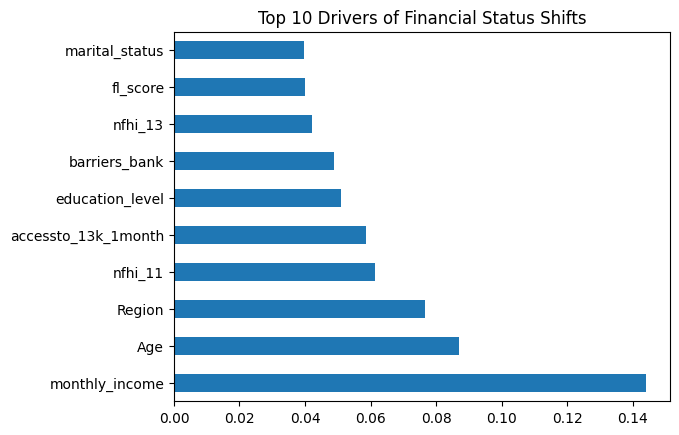

In [167]:
importances = pd.Series(model_rf.feature_importances_, index=X_train_encoded.columns)
importances.nlargest(10).plot(kind='barh')
plt.title("Top 10 Drivers of Financial Status Shifts")
plt.show()

# Confusion Matrix

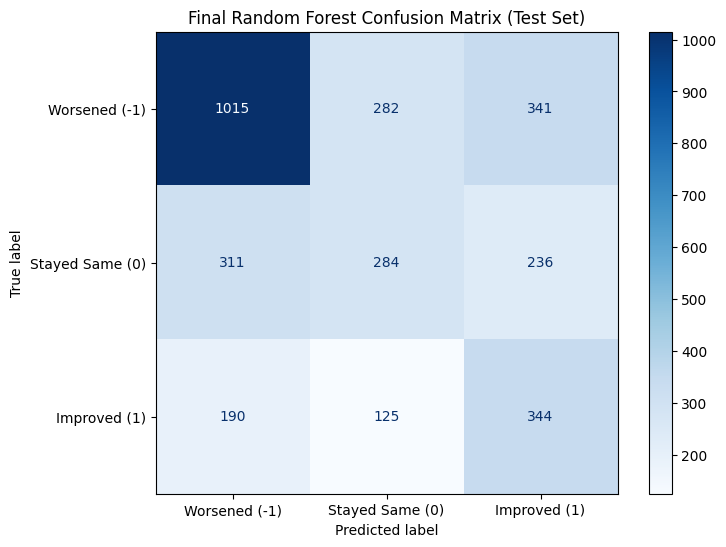

In [168]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Compute the raw confusion matrix values using the correct test variables
cm = confusion_matrix(y_test, y_test_pred_rf, labels=[-1, 0, 1])

# 2. Set up the display with human-readable labels matching your outcome_map
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Worsened (-1)", "Stayed Same (0)", "Improved (1)"]
)

# 3. Plot the matrix with a clean color gradient
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')

plt.title("Final Random Forest Confusion Matrix (Test Set)")
plt.grid(False) # Turn off the grid line overlay for a clean view
plt.show()

# Recommendations

* With all due respect, the model is more likely to predict:
    *  Worsened people as worsened
    *  Improved people as improved
* The model is still likely to hallucinate that people who have stayed the same have actually worsened.
* The model is still better than randomly guessing someone's final financial status by 20%.
* The most significant driver of prediction is someone's monthly salary.